<a href="https://colab.research.google.com/github/aprilianeylani/Clustering/blob/main/2304020185_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fuzzy C-Means (FCM)**
Fuzzy C-Means (FCM) merupakan metode clustering yang memungkinkan setiap data memiliki derajat keanggotaan pada lebih dari satu kelompok, sehingga tidak bersifat kaku seperti metode K-Means. Dengan demikian, setiap data dapat memiliki tingkat kedekatan yang berbeda dengan tiap kelompok, misalnya suatu data dapat termasuk 70% pada cluster A dan 30% pada cluster B. Metode ini diperkenalkan oleh James C. Dunn dan dikembangkan oleh James C. Bezdek, serta banyak digunakan dalam bidang data mining karena kemampuannya dalam mengelompokkan data yang memiliki karakteristik yang saling tumpang tindih.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving iris.csv to iris (1).csv


In [ ]:
#pemanggilan data
import pandas as pd
import matplotlib.pyplot as plt
df_full = pd.read_csv('iris.csv')

In [ ]:
data.head()

,sepal-length,sepal-width,petal-length,petal-width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df_full.shape

(150, 5)

In [ ]:
columns = list(df_full.columns)
features = columns[:len(columns)-1]
class_labels = list(df_full[columns[-1]])
df = df_full[features]

# **Menentukan Parameter**
Pada tahap ini, digunakan 3 cluster karena pada data Iris terdapat 3 kelas. Parameter MAX_ITER berfungsi sebagai batas maksimum perulangan agar proses tidak berjalan tanpa henti (infinite loop). Selanjutnya, terdapat parameter fuzzy yang mengatur tingkat keanggotaan data pada setiap cluster. Jika nilainya 1, maka hasilnya akan sama seperti metode K-Nearest Neighbors. Pada penelitian ini, nilai fuzzy yang digunakan adalah 1,7.

In [ ]:
# Menentukan jumlah cluster
k = 3

# Menentukan batas maksimum iterasi
MAX_ITER = 100

# Menghitung jumlah data
n = len(df)

# Menentukan parameter fuzzy (derajat keanggotaan)
m = 1.7  # pilih nilai yang lebih dari 1, jika tidak maka hasilnya akan seperti K-Nearest Neighbors (KNN).

# Menampilkan hasil parameter
print("Jumlah cluster (k):", k)
print("Maksimum iterasi:", MAX_ITER)
print("Jumlah data (n):", n)
print("Nilai fuzzy (m):", m)

Jumlah cluster (k): 3
Maksimum iterasi: 100
Jumlah data (n): 150
Nilai fuzzy (m): 1.7


# **Scatter Plots**

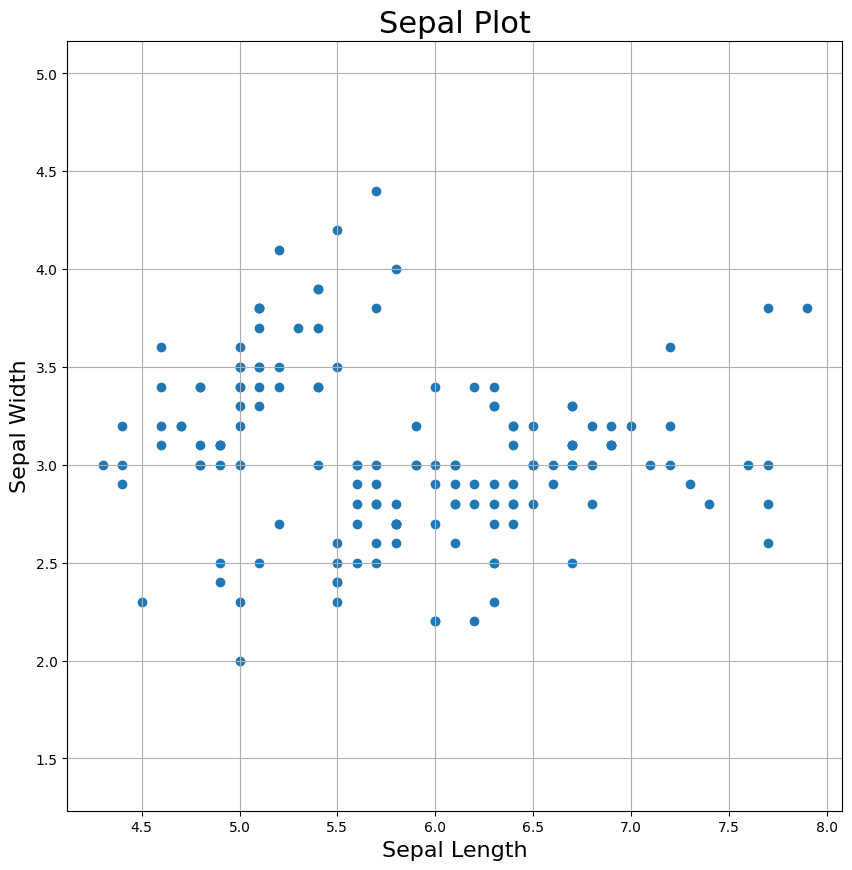

In [ ]:
plt.figure(figsize=(10,10))  # diagram sebar antara panjang sepal dan lebar sepal
plt.scatter(list(df.iloc[:,0]), list(df.iloc[:,1]), marker='o')
plt.axis('equal')
plt.xlabel('Sepal Length', fontsize=16)
plt.ylabel('Sepal Width', fontsize=16)
plt.title('Sepal Plot', fontsize=22)
plt.grid()
plt.show()

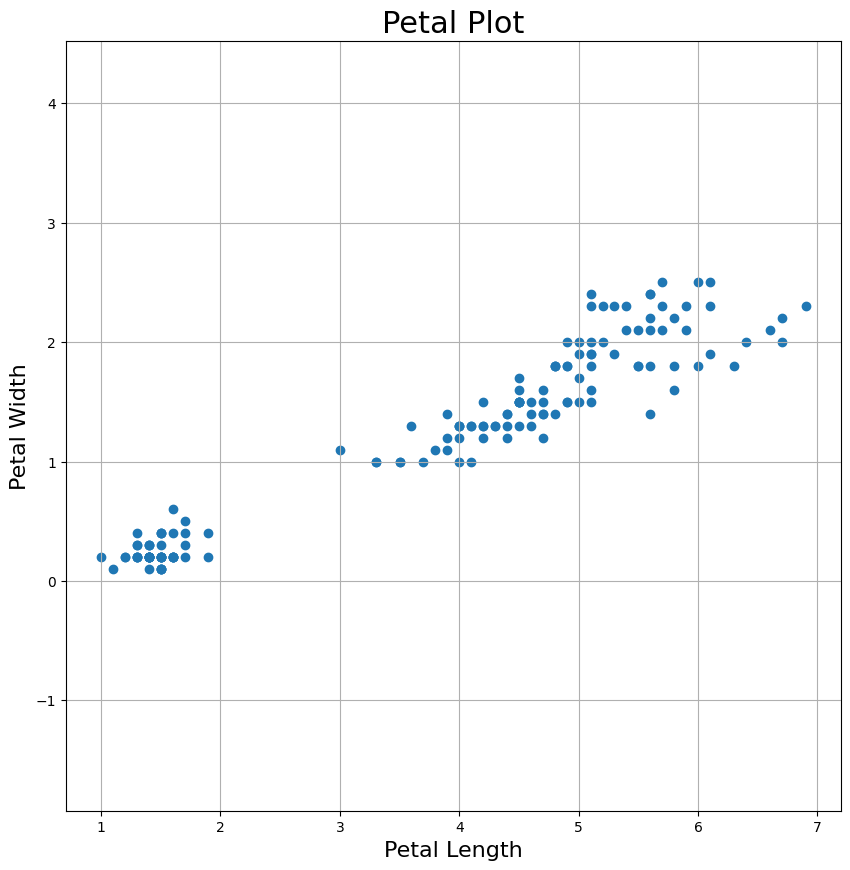

In [ ]:
plt.figure(figsize=(10,10))  # diagram sebar antara panjang petal dan lebar petal
plt.scatter(list(df.iloc[:,2]), list(df.iloc[:,3]), marker='o')
plt.axis('equal')
plt.xlabel('Petal Length', fontsize=16)
plt.ylabel('Petal Width', fontsize=16)
plt.title('Petal Plot', fontsize=22)
plt.grid()
plt.show()

# **Menghitung Akurasi**

In [ ]:
# Menghitung akurasi
# Catatan: Perhitungan akurasi ini hanya berlaku untuk data Iris
def accuracy(cluster_labels, class_labels):
    correct_pred = 0

    # Menentukan label cluster yang paling dominan untuk setiap kelas
    seto = max(set(cluster_labels[0:50]), key=cluster_labels[0:50].count)
    vers = max(set(cluster_labels[50:100]), key=cluster_labels[50:100].count)
    virg = max(set(cluster_labels[100:]), key=cluster_labels[100:].count)

    for i in range(len(df)):
        # Memeriksa kesesuaian antara hasil clustering dan label asli
        if cluster_labels[i] == seto and class_labels[i] == 'Iris-setosa':
            correct_pred += 1
        elif cluster_labels[i] == vers and class_labels[i] == 'Iris-versicolor' and vers != seto:
            correct_pred += 1
        elif cluster_labels[i] == virg and class_labels[i] == 'Iris-virginica' and virg != seto and virg != vers:
            correct_pred += 1

    # Menghitung persentase akurasi
    accuracy = (correct_pred / len(df)) * 100
    return accuracy

# **Inisialisasi Matriks Keanggotaan**

In [ ]:
def initializeMembershipMatrix():  # inisialisasi matriks keanggotaan
    membership_mat = []
    for i in range(n):
        random_num_list = [random.random() for i in range(k)]
        summation = sum(random_num_list)
        temp_list = [x/summation for x in random_num_list]

        flag = temp_list.index(max(temp_list))
        for j in range(0, len(temp_list)):
            if(j == flag):
                temp_list[j] = 1
            else:
                temp_list[j] = 0

        membership_mat.append(temp_list)
    return membership_mat

In [ ]:
membership_mat = initializeMembershipMatrix()

# **Menghitung Pusat Cluster**

In [ ]:
def calculateClusterCenter(membership_mat):  # menghitung pusat cluster
    cluster_mem_val = list(zip(*membership_mat))
    cluster_centers = []
    for j in range(k):
        x = list(cluster_mem_val[j])
        xraised = [p ** m for p in x]
        denominator = sum(xraised)
        temp_num = []
        for i in range(n):
            data_point = list(df.iloc[i])
            prod = [xraised[i] * val for val in data_point]
            temp_num.append(prod)
        numerator = map(sum, list(zip(*temp_num)))
        center = [z / denominator for z in numerator]
        cluster_centers.append(center)
    return cluster_centers

In [ ]:
# Menghitung pusat cluster berdasarkan matriks keanggotaan
# cluster_centers = calculateClusterCenter(membership_mat)
calculateClusterCenter(membership_mat)

[[5.8, 3.002083333333333, 3.69375, 1.15625],
 [5.858333333333333, 3.05625, 3.891666666666667, 1.29375],
 [5.868518518518518,
  3.0981481481481485,
  3.6981481481481477,
  1.151851851851852]]

# **Memperbarui Nilai Keanggotaan**

In [ ]:
def updateMembershipValue(membership_mat, cluster_centers):  # memperbarui nilai keanggotaan
    p = float(2/(m-1))
    for i in range(n):
        x = list(df.iloc[i])
        distances = [np.linalg.norm(np.array(list(map(operator.sub, x, cluster_centers[j])))) for j in range(k)]
        for j in range(k):
            den = sum([math.pow(float(distances[j]/distances[c]), p) for c in range(k)])
            membership_mat[i][j] = float(1/den)
    return membership_mat

# **Menentukan Cluster**

In [ ]:
def getClusters(membership_mat):  # menentukan cluster
    cluster_labels = list()
    for i in range(n):
        max_val, idx = max((val, idx) for (idx, val) in enumerate(membership_mat[i]))
        cluster_labels.append(idx)
    return cluster_labels

Di bawah ini ditunjukkan tiga jenis inisialisasi yang berbeda. Ketika inisialisasi dilakukan pada titik asal (origin), seluruh data akan berkumpul (konvergen) ke dalam satu cluster. Sedangkan pada dua kondisi lainnya, dihasilkan cluster sesuai dengan jumlah yang telah ditentukan sebelumnya.

**1. Fuzzy C-Means dengan pusat cluster berada di titik asal (origin)**

In [ ]:
def fuzzyCMeansClustering():  # iterasi pertama dengan pusat cluster di titik nol
    # Matriks keanggotaan
    membership_mat = initializeMembershipMatrix()
    curr = 0
    acc = []

    # Inisialisasi pusat cluster di titik asal (0,0,0,0)
    cent_temp = [[0, 0, 0, 0],
                 [0, 0, 0, 0],
                 [0, 0, 0, 0]]

    while curr < MAX_ITER:
        if(curr == 0):
            cluster_centers = cent_temp
            print("Cluster Centers:")
            print(np.array(cluster_centers))
        else:
            cluster_centers = calculateClusterCenter(membership_mat)

        # Memperbarui nilai keanggotaan
        membership_mat = updateMembershipValue(membership_mat, cluster_centers)

        # Menentukan label cluster
        cluster_labels = getClusters(membership_mat)

        acc.append(cluster_labels)
        curr += 1

    print("---------------------------")
    print("Matriks Keanggotaan:")
    print(np.array(membership_mat))

    return cluster_labels, cluster_centers, acc

**2. Fuzzy C-Means dengan pusat cluster awal yang dipilih secara acak berdasarkan distribusi normal, dengan nilai rata-rata 0 dan varians 1**

In [ ]:
def fuzzyCMeansClustering():  # iterasi kedua dengan distribusi Gaussian multivariat
    # Matriks keanggotaan
    membership_mat = initializeMembershipMatrix()
    curr = 0
    acc = []

    # Menentukan rata-rata dan kovarians
    mean = [0, 0]
    cov = [[1, 0], [0, 1]]

    lis1, cent_temp = [], []

    # Membuat pusat cluster awal secara acak
    for i in range(0, k):
        Z = list(np.random.multivariate_normal(mean, cov))
        Z1 = list(np.random.multivariate_normal(mean, cov))
        lis1 = Z + Z1
        cent_temp.append(lis1)

    while curr < MAX_ITER:
        if curr == 0:
            cluster_centers = cent_temp
            print("Pusat Cluster:")
            print(np.array(cluster_centers))
        else:
            cluster_centers = calculateClusterCenter(membership_mat)

        # Memperbarui nilai keanggotaan
        membership_mat = updateMembershipValue(membership_mat, cluster_centers)

        # Menentukan label cluster
        cluster_labels = getClusters(membership_mat)

        acc.append(cluster_labels)
        curr += 1

    print("---------------------------")
    print("Matriks Keanggotaan:")
    print(np.array(membership_mat))

    return cluster_labels, cluster_centers, acc

**3. Fuzzy C-Means dengan pusat cluster yang dipilih secara acak dari data**

In [ ]:
def fuzzyCMeansClustering():  # iterasi ketiga dengan vektor acak dari data
    # Matriks keanggotaan
    membership_mat = initializeMembershipMatrix()
    curr = 0
    acc = []

    while curr < MAX_ITER:
        # Menghitung pusat cluster
        cluster_centers = calculateClusterCenter(membership_mat)

        # Memperbarui nilai keanggotaan
        membership_mat = updateMembershipValue(membership_mat, cluster_centers)

        # Menentukan label cluster
        cluster_labels = getClusters(membership_mat)

        acc.append(cluster_labels)

        if curr == 0:
            print("Pusat Cluster:")
            print(np.array(cluster_centers))

        curr += 1

    print("---------------------------")
    print("Matriks Partisi:")
    print(np.array(membership_mat))

    return cluster_labels, cluster_centers, acc

# **Menghitung Akurasi**

In [ ]:
labels, centers, acc = fuzzyCMeansClustering()
a = accuracy(labels, class_labels)

Pusat Cluster:
[[5.85918367 3.13673469 3.70204082 1.1877551 ]
 [5.886      2.948      3.948      1.29      ]
 [5.78627451 3.07843137 3.62745098 1.11960784]]
---------------------------
Matriks Partisi:
[[1.72424329e-04 5.67819162e-05 9.99770794e-01]
 [2.82446451e-03 8.86481003e-04 9.96289054e-01]
 [2.17929773e-03 7.19013163e-04 9.97101689e-01]
 [4.49283135e-03 1.40779918e-03 9.94099369e-01]
 [3.63741759e-04 1.21557690e-04 9.99514701e-01]
 [1.29758903e-02 4.21005758e-03 9.82814052e-01]
 [2.30718744e-03 7.57109076e-04 9.96935703e-01]
 [8.40484306e-06 2.66508464e-06 9.99988930e-01]
 [1.38351228e-02 4.45892768e-03 9.81705950e-01]
 [1.72962558e-03 5.38252020e-04 9.97732122e-01]
 [4.41894904e-03 1.47299186e-03 9.94108059e-01]
 [5.91849425e-04 1.84218020e-04 9.99223933e-01]
 [3.77067942e-03 1.20017378e-03 9.95029147e-01]
 [1.57289028e-02 5.52748695e-03 9.78743610e-01]
 [2.67674268e-02 1.03172071e-02 9.62915366e-01]
 [4.74741073e-02 1.84083981e-02 9.34117495e-01]
 [9.16970181e-03 3.27260430e-0

In [ ]:
acc_lis = []
for i in range(0,len(acc)):
    val = accuracy(acc[i], class_labels)
    acc_lis.append(val)

In [ ]:
acc_lis = np.array(acc_lis)  # menghitung akurasi dan standar deviasi sebanyak 100 kali
print("mean=", np.mean(acc_lis))
print("Std dev=", np.std(acc_lis))

mean= 87.91333333333328
Std dev= 4.965351056180332


In [ ]:
print("Accuracy = " + str(round(a, 2)))

Accuracy = 88.67


In [ ]:
print("Vektor pusat cluster:")  # pusat cluster akhir
print(np.array(centers))

Vektor pusat cluster:
[[5.8877322  2.75271885 4.36949728 1.40585918]
 [6.80722429 3.05991213 5.68331178 2.06091097]
 [5.00525867 3.40761295 1.48051039 0.25084584]]


# **Memvisualisasikan Data**

In [ ]:
sepal_df = df_full.iloc[:,0:2]
sepal_df = np.array(sepal_df)

In [ ]:
# Inisialisasi pertama
# m1 = [0,0]
# m2 = [0,0]
# m3 = [0,0]

# Inisialisasi kedua
# m1 = [-0.47534495, -0.16392118]
# m2 = [0.89019389, -1.19440781]
# m3 = [1.29107135, 0.48248487]

# Inisialisasi ketiga (dipilih secara acak dari data)
m1 = random.choice(sepal_df)
m2 = random.choice(sepal_df)
m3 = random.choice(sepal_df)

# Menghitung matriks kovarians
cov1 = np.cov(np.transpose(sepal_df))
cov2 = np.cov(np.transpose(sepal_df))
cov3 = np.cov(np.transpose(sepal_df))

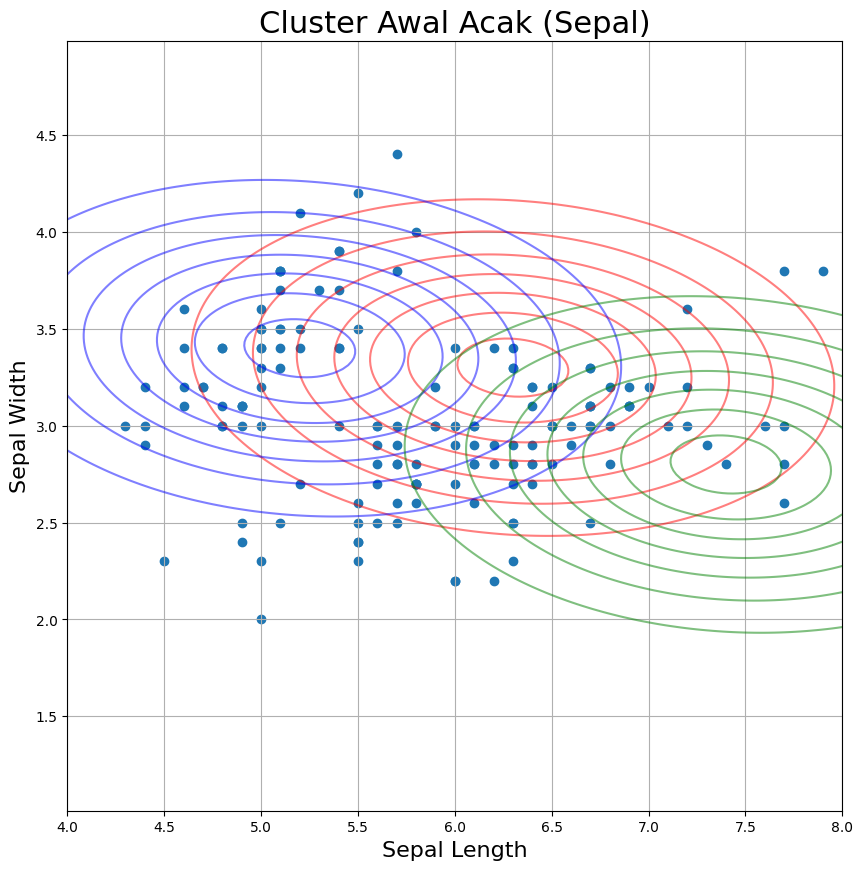

In [ ]:
x1 = np.linspace(4, 8, 150)
x2 = np.linspace(1.5, 4.5, 150)

# x1 = np.linspace(-1, 8, 150)
# x2 = np.linspace(-1, 4.5, 150)

X, Y = np.meshgrid(x1, x2)

Z1 = multivariate_normal(m1, cov1)
Z2 = multivariate_normal(m2, cov2)
Z3 = multivariate_normal(m3, cov3)

pos = np.empty(X.shape + (2,))  # membuat array baru sesuai bentuk yang ditentukan tanpa mengisi nilai awal
pos[:, :, 0] = X
pos[:, :, 1] = Y

plt.figure(figsize=(10, 10))  # membuat gambar dan menentukan ukurannya
plt.scatter(sepal_df[:, 0], sepal_df[:, 1], marker='o')

plt.contour(X, Y, Z1.pdf(pos), colors="r", alpha=0.5)
plt.contour(X, Y, Z2.pdf(pos), colors="b", alpha=0.5)
plt.contour(X, Y, Z3.pdf(pos), colors="g", alpha=0.5)

plt.axis('equal')  # menyamakan skala kedua sumbu
plt.xlabel('Sepal Length', fontsize=16)  # sumbu X
plt.ylabel('Sepal Width', fontsize=16)  # sumbu Y
plt.title('Cluster Awal Acak (Sepal)', fontsize=22)  # judul plot
plt.grid()  # menampilkan garis bantu/grid
plt.show()

In [ ]:
petal_df = df_full.iloc[:,2:4]
petal_df = np.array(petal_df)

In [ ]:
# Inisialisasi pertama
# m1 = [0,0]
# m2 = [0,0]
# m3 = [0,0]

# Inisialisasi kedua
# m1 = [-0.8005044 , -0.7017542]
# m2 = [-2.17962154, -0.96475807]
# m3 = [-0.68988961,  0.54596565]

# Inisialisasi ketiga (dipilih secara acak dari data)
m1 = random.choice(petal_df)
m2 = random.choice(petal_df)
m3 = random.choice(petal_df)

# Menghitung matriks kovarians
cov1 = np.cov(np.transpose(petal_df))
cov2 = np.cov(np.transpose(petal_df))
cov3 = np.cov(np.transpose(petal_df))

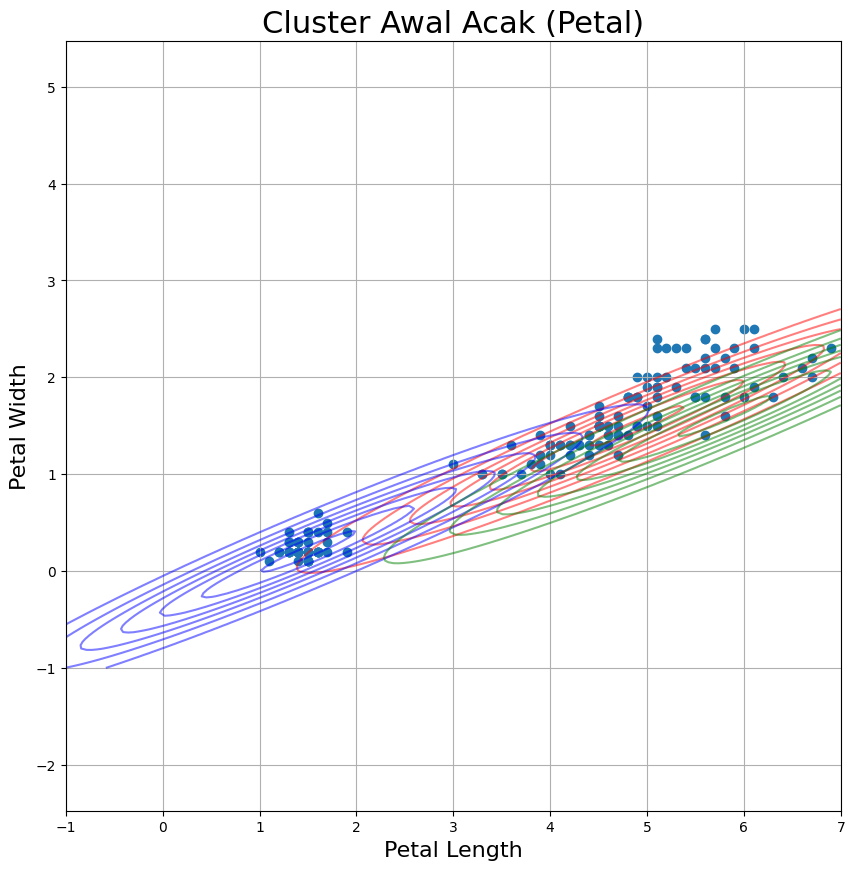

In [ ]:
# x1 = np.linspace(0.5,7,150)
# x2 = np.linspace(-1,4,150)

x1 = np.linspace(-1, 7, 150)   # membuat rentang nilai sumbu X (panjang petal)
x2 = np.linspace(-1, 4, 150)   # membuat rentang nilai sumbu Y (lebar petal)

X, Y = np.meshgrid(x1, x2)     # membuat grid koordinat

# Membuat distribusi Gaussian untuk tiap cluster
Z1 = multivariate_normal(m1, cov1)
Z2 = multivariate_normal(m2, cov2)
Z3 = multivariate_normal(m3, cov3)

# Membuat array posisi (x,y)
pos = np.empty(X.shape + (2,))  # membuat array kosong sesuai bentuk grid
pos[:, :, 0] = X
pos[:, :, 1] = Y

plt.figure(figsize=(10,10))  # membuat gambar dengan ukuran tertentu

# Menampilkan data asli (scatter plot)
plt.scatter(petal_df[:, 0], petal_df[:, 1], marker='o')

# Menampilkan kontur distribusi Gaussian (cluster awal)
plt.contour(X, Y, Z1.pdf(pos), colors="r", alpha=0.5)
plt.contour(X, Y, Z2.pdf(pos), colors="b", alpha=0.5)
plt.contour(X, Y, Z3.pdf(pos), colors="g", alpha=0.5)

plt.axis('equal')  # menyamakan skala sumbu X dan Y
plt.xlabel('Petal Length', fontsize=16)  # label sumbu X
plt.ylabel('Petal Width', fontsize=16)  # label sumbu Y
plt.title('Cluster Awal Acak (Petal)', fontsize=22)  # judul grafik
plt.grid()  # menampilkan grid
plt.show()  # menampilkan grafik

In [ ]:
# mencari nilai yang paling sering muncul (modus)
seto = max(set(labels[0:50]), key=labels[0:50].count)
vers = max(set(labels[50:100]), key=labels[50:100].count)
virg = max(set(labels[100:]), key=labels[100:].count)

In [ ]:
#sepal
s_mean_clus1 = np.array([centers[seto][0],centers[seto][1]])
s_mean_clus2 = np.array([centers[vers][0],centers[vers][1]])
s_mean_clus3 = np.array([centers[virg][0],centers[virg][1]])

In [ ]:
values = np.array(labels)  # label cluster

# mencari nilai untuk ketiga spesies
searchval_seto = seto
searchval_vers = vers
searchval_virg = virg

# mencari indeks data untuk masing-masing spesies
ii_seto = np.where(values == searchval_seto)[0]
ii_vers = np.where(values == searchval_vers)[0]
ii_virg = np.where(values == searchval_virg)[0]

ind_seto = list(ii_seto)
ind_vers = list(ii_vers)
ind_virg = list(ii_virg)

In [ ]:
sepal_df = df_full.iloc[:,0:2]

In [ ]:
seto_df = sepal_df[sepal_df.index.isin(ind_seto)]
vers_df = sepal_df[sepal_df.index.isin(ind_vers)]
virg_df = sepal_df[sepal_df.index.isin(ind_virg)]

In [ ]:
cov_seto = np.cov(np.transpose(np.array(seto_df)))
cov_vers = np.cov(np.transpose(np.array(vers_df)))
cov_virg = np.cov(np.transpose(np.array(virg_df)))

In [ ]:
sepal_df = np.array(sepal_df)

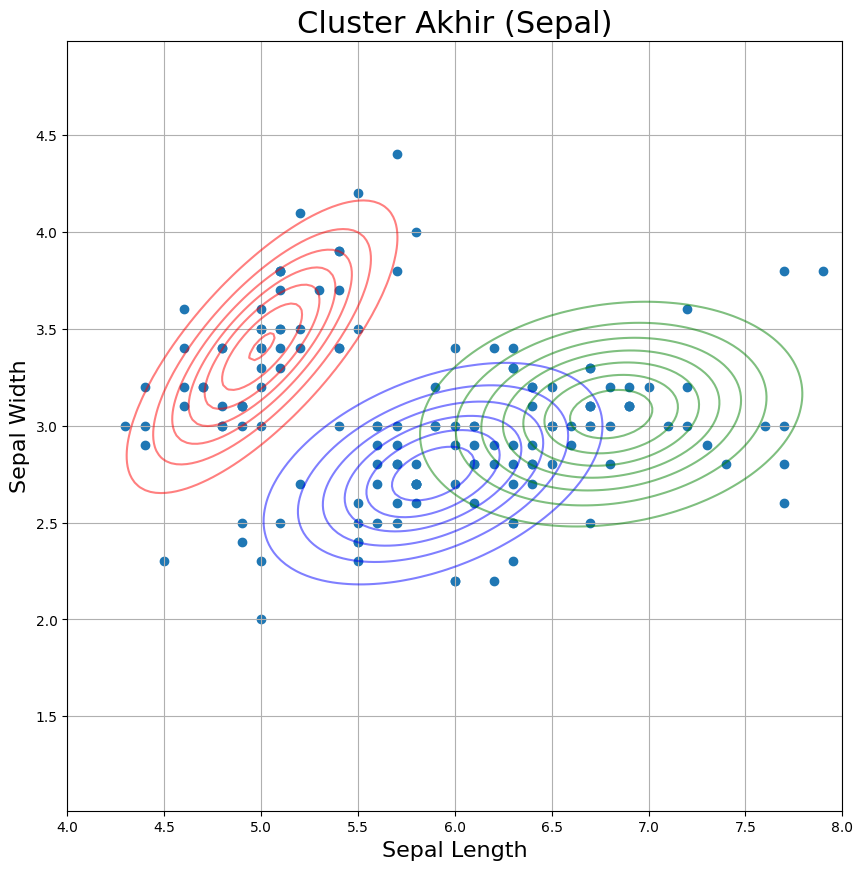

In [ ]:
x1 = np.linspace(4, 8, 150)
x2 = np.linspace(1.5, 4.5, 150)
X, Y = np.meshgrid(x1, x2)  # membuat grid koordinat

# Membuat distribusi Gaussian berdasarkan pusat cluster akhir
Z1 = multivariate_normal(s_mean_clus1, cov_seto)
Z2 = multivariate_normal(s_mean_clus2, cov_vers)
Z3 = multivariate_normal(s_mean_clus3, cov_virg)

# Membuat array posisi (x,y)
pos = np.empty(X.shape + (2,))  # membuat array kosong sesuai bentuk grid
pos[:, :, 0] = X
pos[:, :, 1] = Y

plt.figure(figsize=(10,10))  # membuat gambar dengan ukuran tertentu

# Menampilkan data asli (scatter plot)
plt.scatter(sepal_df[:, 0], sepal_df[:, 1], marker='o')

# Menampilkan kontur cluster akhir
plt.contour(X, Y, Z1.pdf(pos), colors="r", alpha=0.5)
plt.contour(X, Y, Z2.pdf(pos), colors="b", alpha=0.5)
plt.contour(X, Y, Z3.pdf(pos), colors="g", alpha=0.5)

plt.axis('equal')  # menyamakan skala sumbu
plt.xlabel('Sepal Length', fontsize=16)  # sumbu X
plt.ylabel('Sepal Width', fontsize=16)  # sumbu Y
plt.title('Cluster Akhir (Sepal)', fontsize=22)  # judul grafik
plt.grid()  # menampilkan grid
plt.show()

In [ ]:
#petal
p_mean_clus1 = np.array([centers[seto][2],centers[seto][3]])
p_mean_clus2 = np.array([centers[vers][2],centers[vers][3]])
p_mean_clus3 = np.array([centers[virg][2],centers[virg][3]])

In [ ]:
petal_df = df_full.iloc[:,2:4]

In [ ]:
seto_df = petal_df[petal_df.index.isin(ind_seto)]
vers_df = petal_df[petal_df.index.isin(ind_vers)]
virg_df = petal_df[petal_df.index.isin(ind_virg)]

In [ ]:
cov_seto = np.cov(np.transpose(np.array(seto_df)))
cov_vers = np.cov(np.transpose(np.array(vers_df)))
cov_virg = np.cov(np.transpose(np.array(virg_df)))

In [ ]:
petal_df = np.array(petal_df)

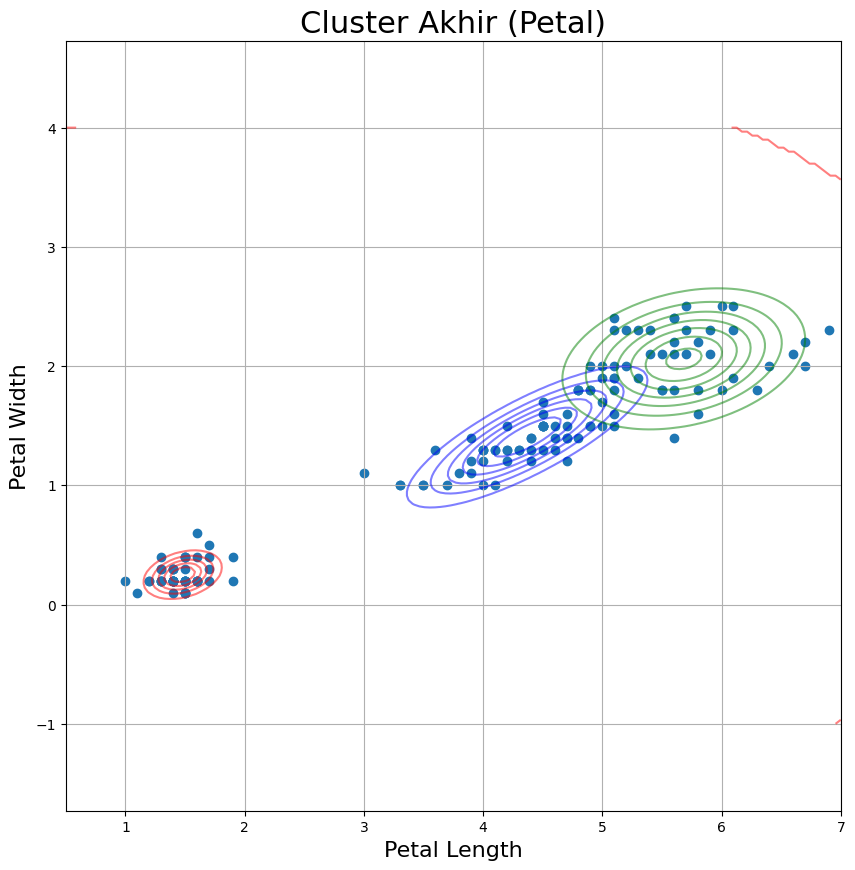

In [ ]:
x1 = np.linspace(0.5, 7, 150)
x2 = np.linspace(-1, 4, 150)
X, Y = np.meshgrid(x1, x2)  # membuat grid koordinat

# Membuat distribusi Gaussian berdasarkan pusat cluster akhir
Z1 = multivariate_normal(p_mean_clus1, cov_seto)
Z2 = multivariate_normal(p_mean_clus2, cov_vers)
Z3 = multivariate_normal(p_mean_clus3, cov_virg)

# Membuat array posisi (x,y)
pos = np.empty(X.shape + (2,))  # membuat array kosong sesuai bentuk grid
pos[:, :, 0] = X
pos[:, :, 1] = Y

plt.figure(figsize=(10,10))  # membuat gambar dengan ukuran tertentu

# Menampilkan data asli (scatter plot)
plt.scatter(petal_df[:, 0], petal_df[:, 1], marker='o')

# Menampilkan kontur cluster akhir
plt.contour(X, Y, Z1.pdf(pos), colors="r", alpha=0.5)
plt.contour(X, Y, Z2.pdf(pos), colors="b", alpha=0.5)
plt.contour(X, Y, Z3.pdf(pos), colors="g", alpha=0.5)

plt.axis('equal')  # menyamakan skala sumbu X dan Y
plt.xlabel('Petal Length', fontsize=16)  # label sumbu X
plt.ylabel('Petal Width', fontsize=16)  # label sumbu Y
plt.title('Cluster Akhir (Petal)', fontsize=22)  # judul grafik
plt.grid()  # menampilkan grid
plt.show()